Logistic Regression:


Contributions:
1. https://www.ibm.com/think/topics/logistic-regression
2. https://www.analyticsvidhya.com/blog/2023/01/a-comprehensive-guide-to-ols-regression-part-1/

In [10]:
# Libraries:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
import os
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, accuracy_score
import numpy as np

In [11]:
# Data import and pre-processing:

os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("momentum_labeled.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','trend_bin']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_features = pd.read_csv("final_features.csv", parse_dates=['Date'])
df_features = df_features.set_index('Date')


data = pd.concat([df_features,df_factor], axis=1, join='inner')
data = data.dropna()

print(data.columns)

Index(['Momentum_vs_Value_trend', 'Value_vs_Quality_trend',
       'Momentum_vs_Quality_trend', 'SA_NB_Level_QS', 'SA_NB_Level_TS',
       'SA_NB_Slope_TS', 'SA_RB_R2_QS', 'SA_RB_Slope_TS', 'US_NB_R2',
       'US_NB_Level_TS', 'US_NB_Slope_TS', 'US_RB_R2', 'US_RB_Slope_TS',
       'SA_CDS_Slope', 'SA_CDS_R2', 'SA_CDS_Slope_QS', 'SA_CDS_R2_QS',
       'USDZAR_Vol_Level.1', 'USDZARVON.Curncy_QS.1', 'EURUSDV1Y.Curncy_QS',
       'LocalEquityVol3', 'GlobalEquityVol3', 'VolTermStructPC1',
       'VolSpread6M', 'VixSaviSpread', 'SA_NB_Curvature', 'SA_NB_Curvature_QS',
       'SA_NB_R2_QS', 'SA_RB_Level_TS', 'US_NB_Level', 'US_NB_Curvature',
       'US_NB_Curvature_QS', 'US_RB_Curvature', 'US_RB_R2_QS',
       'SA_CDS_Curvature', 'USDZAR_Vol_Slope.1', 'USDEUR_Vol_Level',
       'USDEUR_Vol_Slope', 'VixMoveSpread', 'trend_bin'],
      dtype='object')


In [12]:

class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, tol=1e-4):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.tol = tol
        self.beta = None
        self.cost_history = []
    
    def sigmoid(self, z):
        # Stable sigmoid
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))
    
    def cost_function(self, X, y, beta):
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        # To avoid log(0)
        h = np.clip(h, 1e-10, 1 - 1e-10)
        cost = (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))
        return cost
    
    def gradient_descent(self, X, y, beta):
        m = len(y)
        for i in range(self.num_iterations):
            h = self.sigmoid(X.dot(beta))
            gradient = (1/m) * X.T.dot(h - y)
            new_beta = beta - self.learning_rate * gradient
            
            # Check for convergence
            if np.linalg.norm(new_beta - beta) < self.tol:
                print(f"Converged after {i} iterations")
                break
                
            beta = new_beta
            self.cost_history.append(self.cost_function(X, y, beta))
        return beta
    
    def fit(self, X, y):
        # Add intercept term and initialize beta
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.beta = np.zeros(X_b.shape[1])
        self.beta = self.gradient_descent(X_b, y, self.beta)
    
    def predict_proba(self, X):
        # Returns probability estimates
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b.dot(self.beta))
    
    def predict(self, X, threshold=0.5):
        # Returns class labels
        return (self.predict_proba(X) >= threshold).astype(int)



In [13]:
def combinatorial_purged_cv(n_samples, n_splits=5, test_size=0.2, purge=5, embargo=5):
    """
    Generator for CPCV splits.
    """
    fold_size = int(n_samples * test_size) if isinstance(test_size, float) else test_size
    indices = np.arange(n_samples)

    for start in range(0, n_samples - fold_size, fold_size):
        test_idx = indices[start:start+fold_size]

        purge_start = max(0, start - purge)
        embargo_end = min(n_samples, start + fold_size + embargo)

        train_idx = np.concatenate([indices[:purge_start], indices[embargo_end:]])
        yield train_idx, test_idx

In [14]:
def cpcv_validation(X, y, model_class, param_grid, n_splits=5, test_size=0.2, purge=5, embargo=5):
    best_score = -np.inf
    best_params = None
    results = []

    for params in ParameterGrid(param_grid):
        scores = []

        for train_idx, test_idx in combinatorial_purged_cv(len(y), n_splits, test_size, purge, embargo):
            model = model_class(**params)
            model.fit(X[train_idx], y[train_idx])
            y_pred = model.predict(X[test_idx])
            score = accuracy_score(y[test_idx], y_pred)
            scores.append(score)

        avg_score = np.mean(scores)
        results.append((params, avg_score))

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

    return best_params, best_score, results


In [15]:
def walk_forward_validation(X, y, model_class, initial_train_size, test_size=1, **model_params):
    n_samples = len(y)
    predictions = []
    probas = []
    true_values = []

    train_end = initial_train_size
    while train_end + test_size <= n_samples:
        # Split
        X_train, y_train = X[:train_end], y[:train_end]
        X_test, y_test = X[train_end:train_end+test_size], y[train_end:train_end+test_size]

        # Train
        model = model_class(**model_params)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        predictions.extend(y_pred)
        probas.extend(y_proba)
        true_values.extend(y_test)

        # Move forward
        train_end += test_size

    return np.array(predictions), np.array(probas), np.array(true_values)



In [16]:
# Implementation:
X_df = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
X_df = np.nan_to_num(X_df, nan=np.nan, posinf=1e10, neginf=-1e10)  # Convert inf to large finite numbers

scaler = StandardScaler()
X = scaler.fit_transform(X_df)

param_grid = {
    "learning_rate": [0.5, 1, 0.1, 0.01,0.001],
    "num_iterations": [500, 1000],
    "tol": [1e-3, 1e-4]
}

best_params, best_score, cpcv_results = cpcv_validation(
    X, y, LogisticRegression, param_grid, n_splits=5, test_size=0.2, purge=5, embargo=5
)

#print("Best CPCV parameters:", best_params)
#print("Best CPCV score:", best_score)

# Walk-forward using best params
preds, probas, true_vals = walk_forward_validation(
    X, y, LogisticRegression, initial_train_size=50, test_size=1, **best_params
)


Converged after 763 iterations
Converged after 740 iterations
Converged after 727 iterations
Converged after 673 iterations
Converged after 798 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations
Converged after 0 iterations


In [17]:

def display_walkforward_results(y_true, y_pred, y_proba=None):
    # Performance metrics
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)

    print("Walk-forward Performance:")
    print(f"Accuracy : {acc:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"Precision: {prec:.3f}")

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        print(f"ROC AUC  : {auc:.3f}")
        print(f"PR  AUC  : {pr_auc:.3f}")

    # --- Plot predictions vs actual ---
    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="True", marker="o")
    plt.plot(y_pred, label="Predicted", marker="x")
    plt.title("Walk-forward Predictions vs True Values")
    plt.xlabel("Time step")
    plt.ylabel("Class")
    plt.legend()
    plt.show()

    # --- Plot probabilities ---
    if y_proba is not None:
        plt.figure(figsize=(12,4))
        plt.plot(y_proba, label="Predicted probability", color="blue")
        plt.title("Walk-forward Predicted Probabilities")
        plt.xlabel("Time step")
        plt.ylabel("Probability of Class=1")
        plt.legend()
        plt.show()

        # --- ROC Curve ---
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()

        # --- Precision-Recall Curve ---
        precs, recs, _ = precision_recall_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(recs, precs, label=f"PR Curve (AP = {pr_auc:.3f})", color="purple")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.legend()
        plt.show()

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


Walk-forward Performance:
Accuracy : 0.694
F1 Score : 0.645
Recall   : 0.588
Precision: 0.714
ROC AUC  : 0.693
PR  AUC  : 0.738


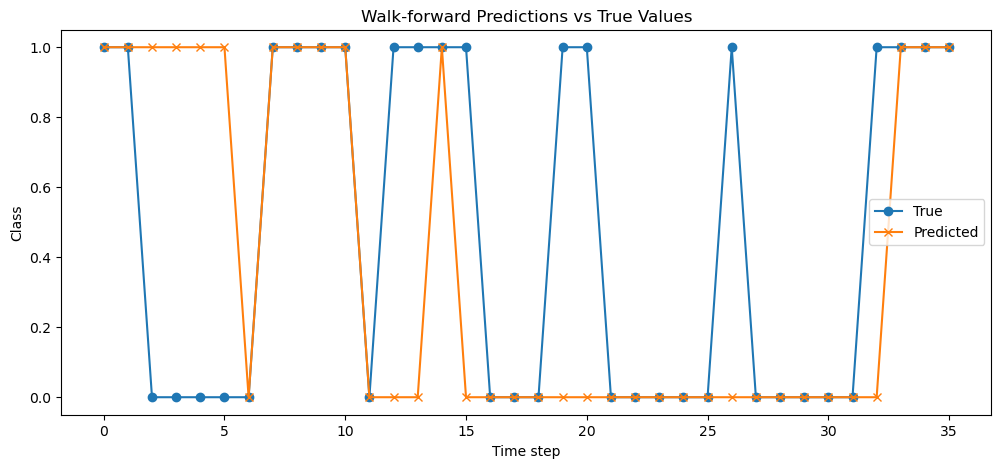

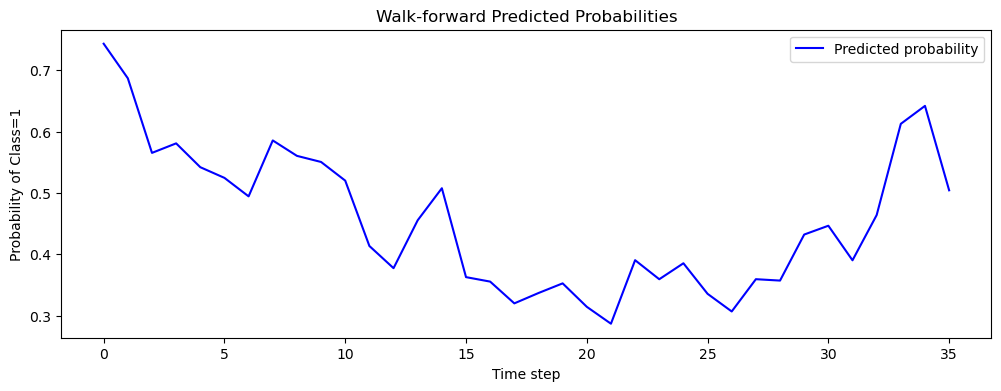

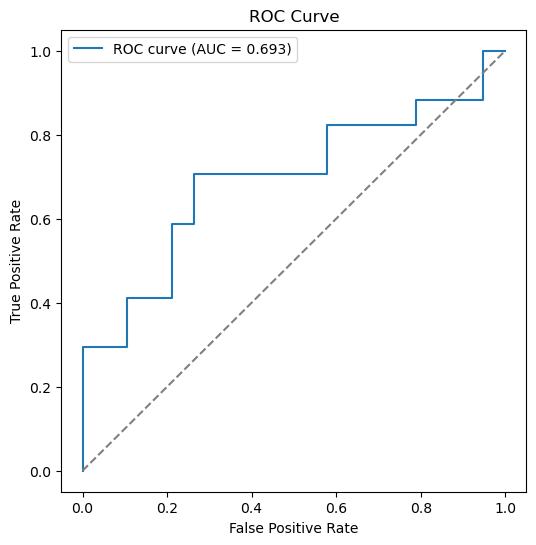

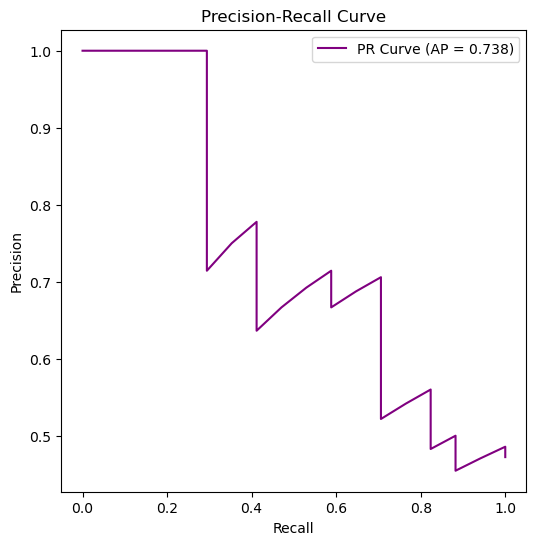

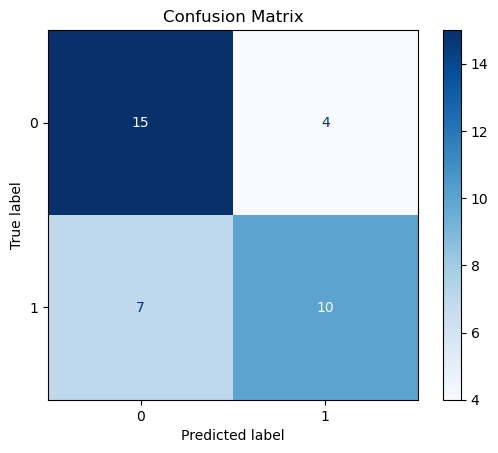

In [18]:
# Run walk-forward with tuned params
y_pred, y_proba, y_true = walk_forward_validation(
    X, y, LogisticRegression, initial_train_size=94, test_size=36, **best_params
)

display_walkforward_results(y_true, y_pred, y_proba)